## Teoría: MLP vs RNN vs LSTM vs BiLSTM

En posts anteriores hemos cubierto muchísimos temas relacionados con `redes neuronales`, sin embargo en todos los ejemplos y aplicaciones hemos usado siempre la misma `arquitectura`: el `Perceptrón Multicapa` (MLP).

![](https://www.researchgate.net/profile/Mohamed_Zahran6/publication/303875065/figure/fig4/AS:371118507610123@1465492955561/A-hypothetical-example-of-Multilayer-Perceptron-Network.png)

En una red *feed forward* la información solo fluye en una dirección. Una `red recurrente` añade conexiones hacia atrás:

$$ \mathbf{y}_t = \mathbf{W}_y f(\mathbf{W}_x \mathbf{x}_t + \mathbf{W}_h \mathbf{h}_{t-1}) $$

Esto permite a la RNN tener **memoria** de pasos anteriores, algo imposible en el MLP.

![](https://i.stack.imgur.com/b4sus.jpg)

La tipología *many-to-one* — usar toda la secuencia para predecir un único valor futuro — es nuestro caso de uso en este laboratorio.

## Configuración inicial



In [70]:
import random
random.seed(42)

import numpy as np
np.random.seed(42)

import pandas as pd
import matplotlib.pyplot as plt
import math

import torch
import torch.nn as nn
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {dispositivo}')
if dispositivo == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU



## Dataset EUR/USD (FRED)

In [71]:
from pathlib import Path
import pandas_datareader.data as web
from datetime import datetime

archivo_fx_local = Path('DEXUSEU.csv')
if archivo_fx_local.exists():
    datos_fx = pd.read_csv(archivo_fx_local)
    columna_fecha = 'observation_date' if 'observation_date' in datos_fx.columns else 'DATE'
    columna_valor = 'DEXUSEU' if 'DEXUSEU' in datos_fx.columns else 'close'
    datos_fx = datos_fx[[columna_fecha, columna_valor]].rename(columns={columna_fecha: 'DATE', columna_valor: 'close'})
    datos_fx['DATE'] = pd.to_datetime(datos_fx['DATE'], errors='coerce')
    datos_fx['close'] = pd.to_numeric(datos_fx['close'], errors='coerce')
    print(f'Datos cargados desde archivo local: {archivo_fx_local}')
else:
    datos_fx = web.DataReader(
        'DEXUSEU',
        'fred',
        start=datetime(2015, 1, 1),
        end=datetime(2024, 12, 31)
    ).reset_index()
    datos_fx.columns = ['DATE', 'close']
    print('Datos descargados desde FRED')

datos_fx = datos_fx.dropna(subset=['DATE']).drop_duplicates(subset='DATE', keep='last')
datos_fx = datos_fx.sort_values('DATE').set_index('DATE')
datos_fx['close'] = pd.to_numeric(datos_fx['close'], errors='coerce')

faltantes_iniciales = int(datos_fx['close'].isna().sum())
datos_fx.loc[datos_fx['close'] <= 0, 'close'] = np.nan

q1, q3 = datos_fx['close'].quantile([0.25, 0.75])
rango_intercuartil = q3 - q1
limite_inferior, limite_superior = q1 - 3.0 * rango_intercuartil, q3 + 3.0 * rango_intercuartil
mascara_atipicos = (datos_fx['close'] < limite_inferior) | (datos_fx['close'] > limite_superior)
atipicos_tratados = int(mascara_atipicos.sum())
datos_fx.loc[mascara_atipicos, 'close'] = np.nan

indice_completo = pd.date_range(datos_fx.index.min(), datos_fx.index.max(), freq='B')
datos_fx = datos_fx.reindex(indice_completo)
datos_fx.index.name = 'DATE'
datos_fx['close'] = datos_fx['close'].interpolate(method='time', limit_direction='both')
datos_fx = datos_fx.dropna()

print(f'Registros finales: {len(datos_fx):,}')
print(f'Periodo:           {datos_fx.index[0].date()} -> {datos_fx.index[-1].date()}')
print(f'NaN iniciales:     {faltantes_iniciales}')
print(f'Outliers tratados: {atipicos_tratados}')
print('\nPrimeras filas:')
print(datos_fx.head())
print('\nEstadísticas:')
print(datos_fx.describe().round(4))

Datos cargados desde archivo local: DEXUSEU.csv
Registros finales: 2,139
Periodo:           2018-01-02 -> 2026-03-13
NaN iniciales:     93
Outliers tratados: 0

Primeras filas:
             close
DATE              
2018-01-02  1.2050
2018-01-03  1.2030
2018-01-04  1.2064
2018-01-05  1.2039
2018-01-08  1.1973

Estadísticas:
           close
count  2139.0000
mean      1.1228
std       0.0562
min       0.9616
25%       1.0839
50%       1.1212
75%       1.1675
max       1.2488


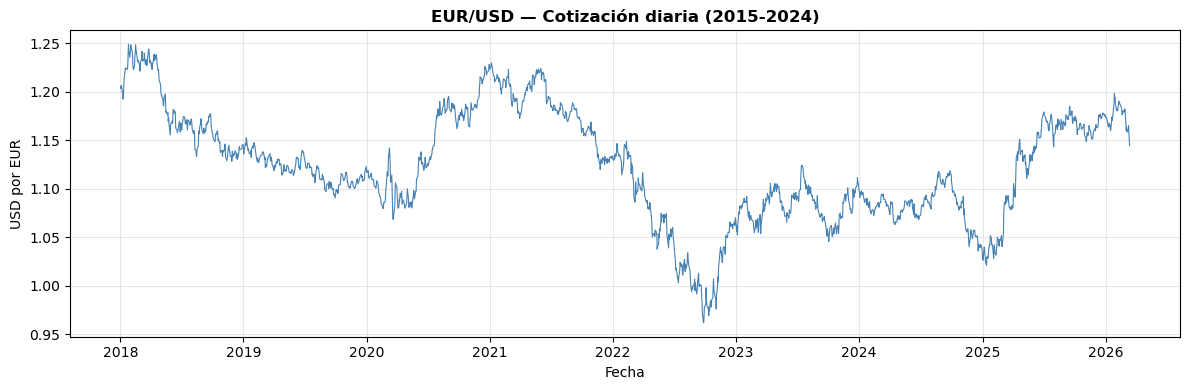

In [72]:
# Gráfico 1: Serie temporal EUR/USD completa
plt.figure(figsize=(12, 4))
plt.plot(datos_fx.index, datos_fx['close'], color='steelblue', linewidth=0.8)
plt.title('EUR/USD — Cotización diaria (2015-2024)', fontsize=12, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('USD por EUR')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
serie_bruta = datos_fx['close'].values
escalador_fx = MinMaxScaler()
serie_normalizada = escalador_fx.fit_transform(serie_bruta.reshape(-1, 1)).flatten()

pasos_ventana = 50

print(f'Serie normalizada — min: {serie_normalizada.min():.4f}, max: {serie_normalizada.max():.4f}')
print(f'pasos_ventana = {pasos_ventana} días de contexto para predecir el siguiente')

Serie normalizada — min: 0.0000, max: 1.0000
pasos_ventana = 50 días de contexto para predecir el siguiente


In [74]:
def crear_dataset(serie, pasos):
    """Crea pares (X, y) con ventana deslizante de tamaño pasos."""
    x_datos, y_datos = [], []
    for i in range(len(serie) - pasos):
        x_datos.append(serie[i:i + pasos])
        y_datos.append(serie[i + pasos])
    return np.array(x_datos), np.array(y_datos)

x_datos, y_datos = crear_dataset(serie_normalizada, pasos_ventana)
print(x_datos.shape)
print(y_datos.shape)

(2089, 50)
(2089,)


In [75]:
tam_entrenamiento = int(len(x_datos) * 0.70)
tam_validacion = int(len(x_datos) * 0.15)

x_entrenamiento = x_datos[:tam_entrenamiento]
y_entrenamiento = y_datos[:tam_entrenamiento]

x_validacion = x_datos[tam_entrenamiento:tam_entrenamiento + tam_validacion]
y_validacion = y_datos[tam_entrenamiento:tam_entrenamiento + tam_validacion]

x_prueba = x_datos[tam_entrenamiento + tam_validacion:]
y_prueba = y_datos[tam_entrenamiento + tam_validacion:]

print(f'Train:      {len(x_entrenamiento):>5} muestras')
print(f'Validación: {len(x_validacion):>5} muestras')
print(f'Test:       {len(x_prueba):>5} muestras')

Train:       1462 muestras
Validación:   313 muestras
Test:         314 muestras



## Parte 2 — Predicción *Naive*

In [76]:
from sklearn.metrics import mean_squared_error

y_pred_ingenua = x_prueba[:, -1]
mse_ingenuo = mean_squared_error(y_prueba, y_pred_ingenua)
print(f'Naive — MSE (escala norm.): {mse_ingenuo:.8f}')

y_prueba_real = escalador_fx.inverse_transform(y_prueba.reshape(-1, 1))
y_ingenua_real = escalador_fx.inverse_transform(y_pred_ingenua.reshape(-1, 1))
rmse_ingenuo = math.sqrt(mean_squared_error(y_prueba_real, y_ingenua_real))
mape_ingenuo = float(np.mean(np.abs((y_prueba_real - y_ingenua_real) / y_prueba_real)) * 100)
print(f'Naive — RMSE (USD real):    {rmse_ingenuo:.5f} USD')
print(f'Naive — MAPE:               {mape_ingenuo:.4f}%')

Naive — MSE (escala norm.): 0.00032534
Naive — RMSE (USD real):    0.00518 USD
Naive — MAPE:               0.3407%


In [77]:
import matplotlib.pyplot as plt
import numpy as np

def graficar_ventanas(serie, y_real=None, y_pred=None):
    """Visualiza múltiples ventanas con su valor real y predicción."""
    serie = np.array(serie)
    if y_real is not None:
        y_real = np.array(y_real)
    if y_pred is not None:
        y_pred = np.array(y_pred)
    filas, columnas = 3, 5
    fig, ejes = plt.subplots(filas, columnas, figsize=(20, 10))
    for fila in range(filas):
        for columna in range(columnas):
            indice = columna + fila * columnas
            if indice >= len(serie):
                continue
            ejes[fila, columna].plot(serie[indice], '.-')
            if y_real is not None:
                ejes[fila, columna].plot([len(serie[indice])], [y_real[indice]], 'bx', markersize=10)
            if y_pred is not None:
                ejes[fila, columna].plot([len(serie[indice])], [y_pred[indice]], 'r.', markersize=10)
    plt.suptitle('Ventanas de test — azul: real | rojo: predicción', fontsize=11)
    plt.tight_layout()
    plt.show()

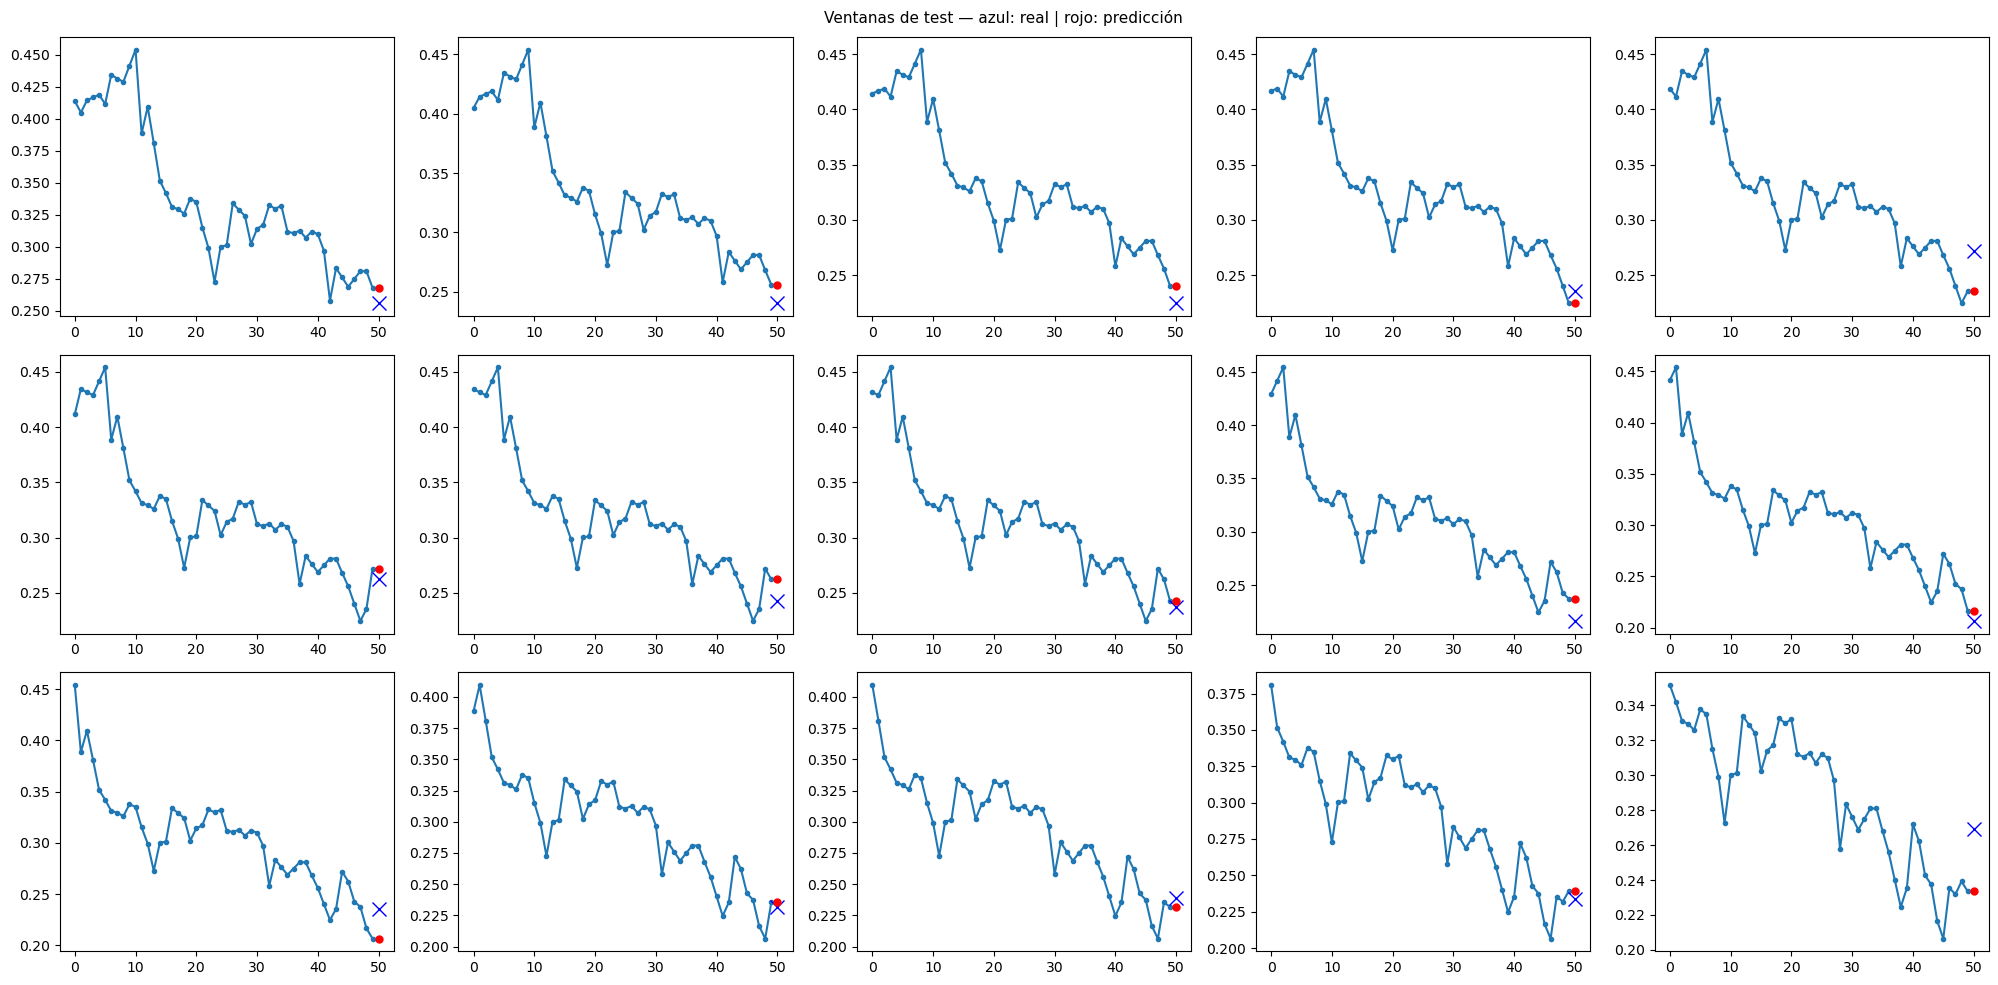

In [78]:
y_pred = x_prueba[:, -1]
graficar_ventanas(x_prueba, y_prueba, y_pred)

##  Perceptrón Multicapa (MLP)


In [79]:
import torch
from torch.utils.data import Dataset, DataLoader

class DatasetSerieTemporal(Dataset):
    """Dataset personalizado para series temporales.
    entrenamiento=True: retorna (X, y). entrenamiento=False: retorna solo X (inferencia)."""
    def __init__(self, x, y=None, entrenamiento=True):
        self.x = x
        self.y = y
        self.entrenamiento = entrenamiento

    def __len__(self):
        return len(self.x)

    def __getitem__(self, indice):
        if self.entrenamiento:
            x = torch.tensor(self.x[indice], dtype=torch.float32)
            y = torch.tensor(self.y[indice], dtype=torch.float32)
            return x, y
        return torch.tensor(self.x[indice], dtype=torch.float32)

conjuntos_datos = {
    'entrenamiento': DatasetSerieTemporal(x_entrenamiento, y_entrenamiento),
    'evaluacion': DatasetSerieTemporal(x_validacion, y_validacion),
    'prueba': DatasetSerieTemporal(x_prueba, y_prueba, entrenamiento=False)
}

cargadores_datos = {
    'entrenamiento': DataLoader(conjuntos_datos['entrenamiento'], shuffle=True, batch_size=64),
    'evaluacion': DataLoader(conjuntos_datos['evaluacion'], shuffle=False, batch_size=64),
    'prueba': DataLoader(conjuntos_datos['prueba'], shuffle=False, batch_size=64)
}

In [80]:
class PerceptronMulticapa(torch.nn.Module):
    def __init__(self, entradas=50, salidas=1):
        super().__init__()
        self.capa_salida = torch.nn.Linear(entradas, salidas)

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        return self.capa_salida(x)

modelo_mlp = PerceptronMulticapa()
print(modelo_mlp)

PerceptronMulticapa(
  (capa_salida): Linear(in_features=50, out_features=1, bias=True)
)


In [81]:
from tqdm import tqdm

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'

def entrenar_modelo(modelo, cargadores, epocas=10):
    modelo.to(dispositivo)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)
    criterio = torch.nn.MSELoss()
    barra = tqdm(range(1, epocas + 1))
    for epoca in barra:
        modelo.train()
        perdidas_entrenamiento = []
        for lote in cargadores['entrenamiento']:
            x_lote, y_lote = lote
            x_lote, y_lote = x_lote.to(dispositivo), y_lote.to(dispositivo)
            optimizador.zero_grad()
            y_estimado = modelo(x_lote).squeeze()
            perdida = criterio(y_estimado, y_lote)
            perdida.backward()
            optimizador.step()
            perdidas_entrenamiento.append(perdida.item())

        modelo.eval()
        perdidas_validacion = []
        with torch.no_grad():
            for lote in cargadores['evaluacion']:
                x_lote, y_lote = lote
                x_lote, y_lote = x_lote.to(dispositivo), y_lote.to(dispositivo)
                y_estimado = modelo(x_lote).squeeze()
                perdidas_validacion.append(criterio(y_estimado, y_lote).item())

        barra.set_postfix(
            entrenamiento=round(np.mean(perdidas_entrenamiento), 5),
            validacion=round(np.mean(perdidas_validacion), 5)
        )


def predecir_modelo(modelo, cargador_split):
    modelo.eval()
    predicciones = []
    with torch.no_grad():
        for lote in cargador_split:
            x_lote = lote.to(dispositivo)
            predicciones.append(modelo(x_lote).squeeze().cpu())
    return torch.cat(predicciones)

In [82]:
entrenar_modelo(modelo_mlp, cargadores_datos, epocas=50)

100%|██████████| 50/50 [00:07<00:00,  6.39it/s, entrenamiento=0.00099, validacion=0.00078]


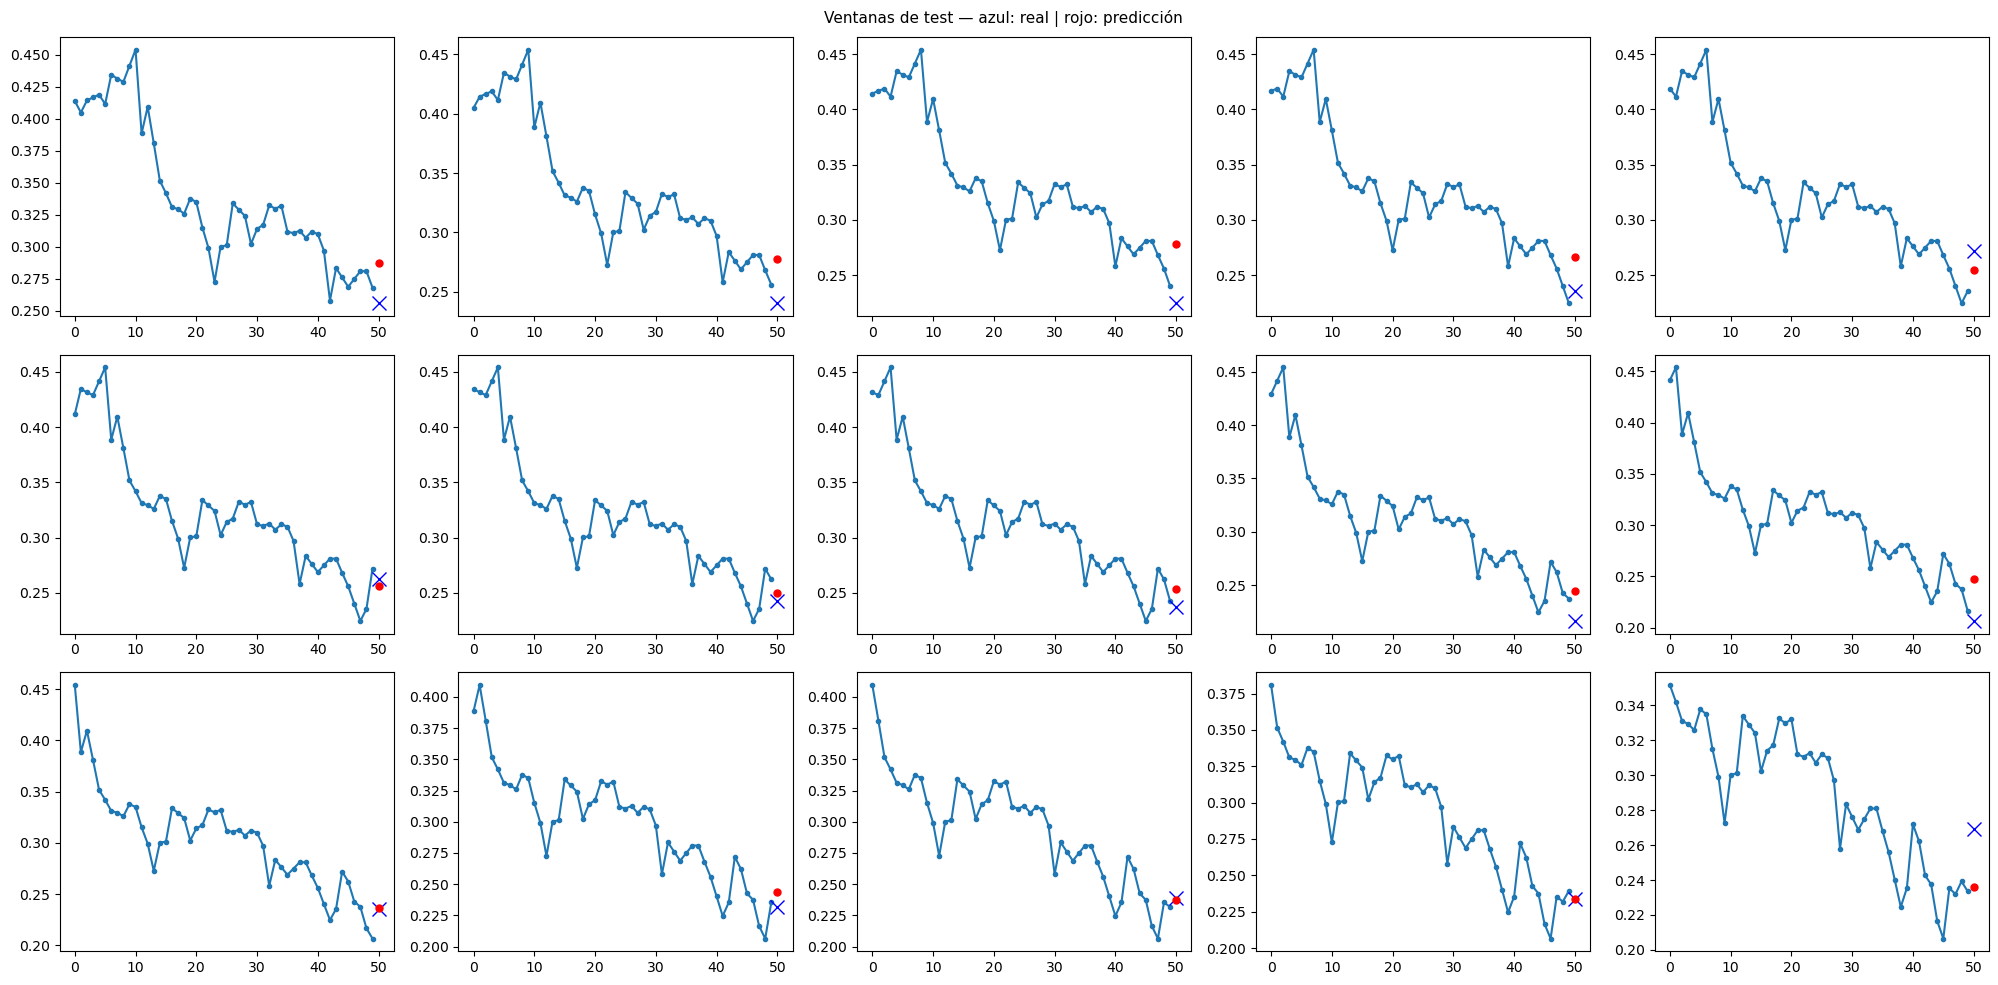

MLP — MSE (normalizado): 0.00119830


In [83]:
y_pred_mlp = predecir_modelo(modelo_mlp, cargadores_datos['prueba'])
graficar_ventanas(x_prueba, y_prueba, y_pred_mlp.numpy())
mse_mlp_norm = mean_squared_error(y_prueba, y_pred_mlp.cpu())
print(f'MLP — MSE (normalizado): {mse_mlp_norm:.8f}')

## Parte 4 — Red LSTM

In [84]:
class ModeloLSTM(torch.nn.Module):
    def __init__(self, tam_entrada=1, tam_oculto=64, num_capas=2):
        super().__init__()
        self.red_lstm = torch.nn.LSTM(
            input_size=tam_entrada,
            hidden_size=tam_oculto,
            num_layers=num_capas,
            batch_first=True,
            dropout=0.2
        )
        self.capa_salida = torch.nn.Linear(tam_oculto, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x, _ = self.red_lstm(x)
        x = self.capa_salida(x[:, -1, :])
        return x

modelo_lstm = ModeloLSTM(tam_entrada=1, tam_oculto=64, num_capas=2)
print(modelo_lstm)

ModeloLSTM(
  (red_lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (capa_salida): Linear(in_features=64, out_features=1, bias=True)
)


In [85]:
entrenar_modelo(modelo_lstm, cargadores_datos, epocas=30)

100%|██████████| 30/30 [00:05<00:00,  5.52it/s, entrenamiento=0.00125, validacion=0.00074]


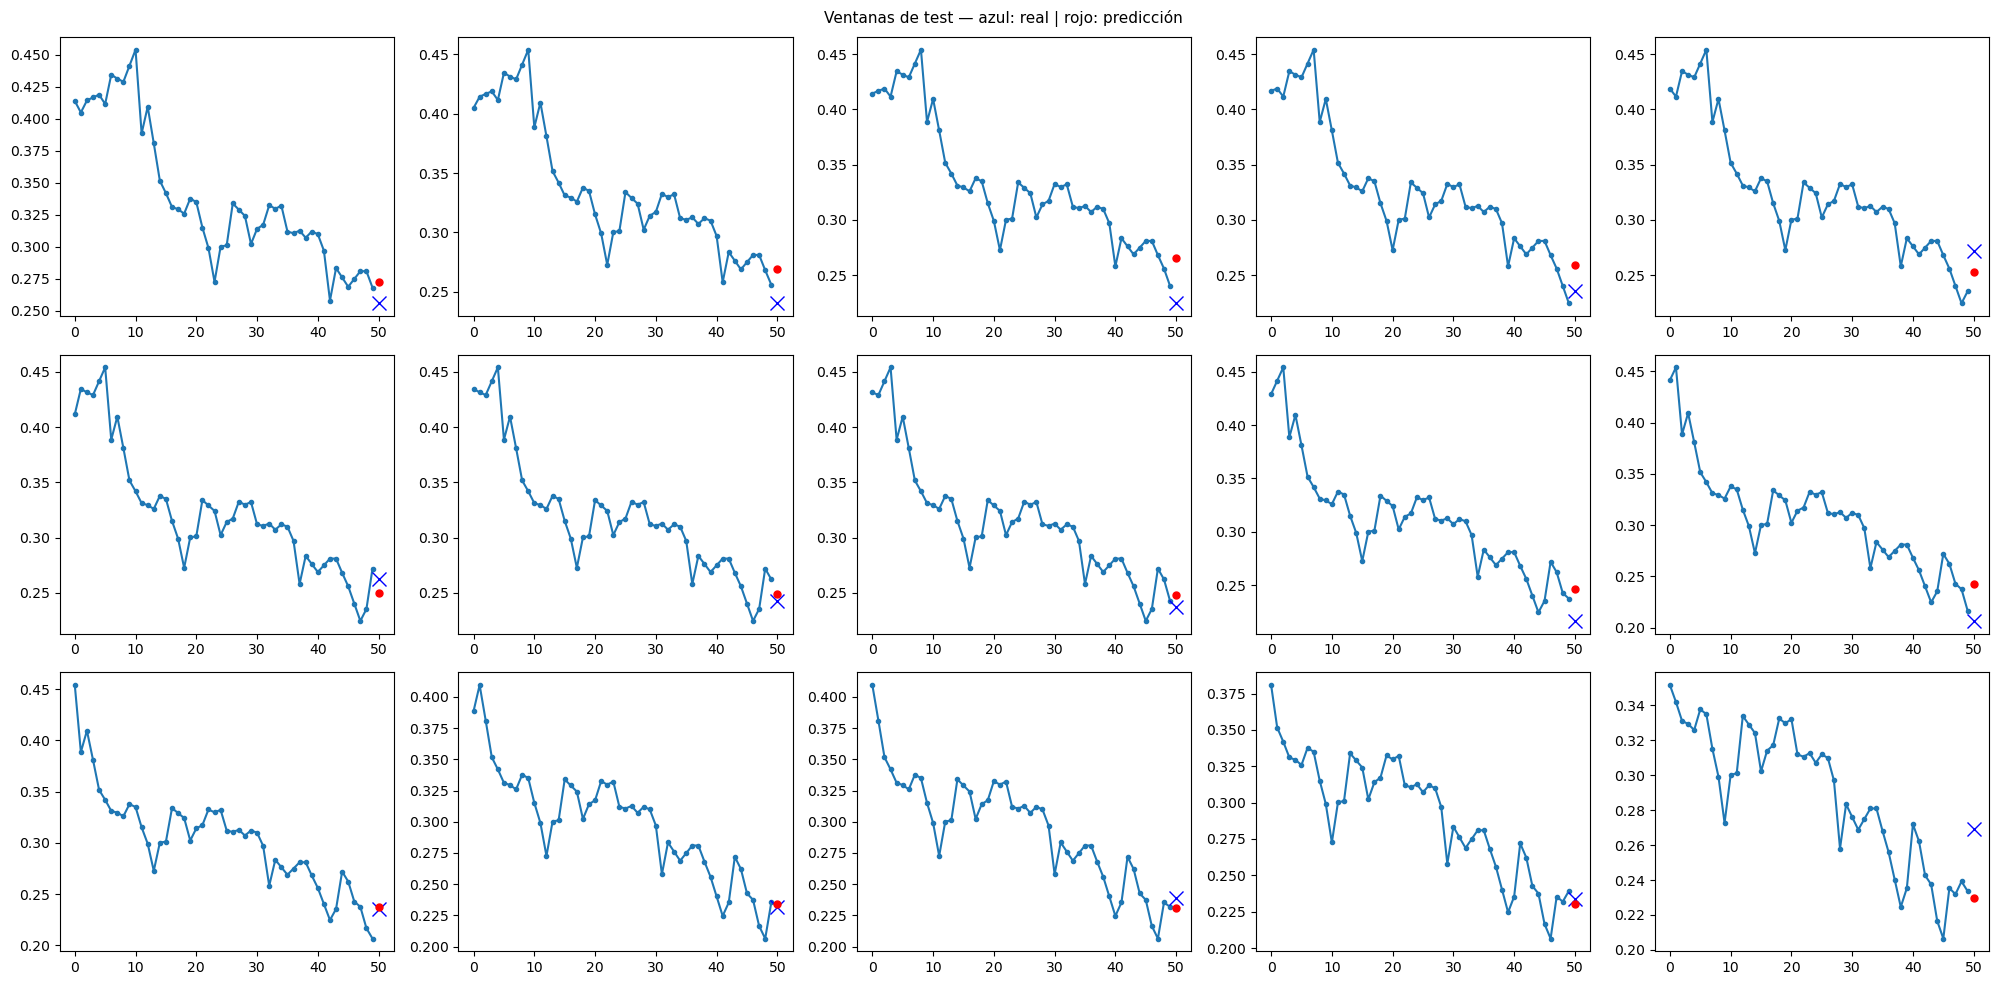

LSTM — MSE (normalizado): 0.00152152


In [86]:
y_pred_lstm = predecir_modelo(modelo_lstm, cargadores_datos['prueba'])
graficar_ventanas(x_prueba, y_prueba, y_pred_lstm.numpy())
mse_lstm_norm = mean_squared_error(y_prueba, y_pred_lstm.cpu())
print(f'LSTM — MSE (normalizado): {mse_lstm_norm:.8f}')

##  Modelo Pre-entrenado

In [87]:
import os

torch.save(modelo_lstm.state_dict(), 'lstm_eurusd_pretrained.pt')
print('Modelo guardado: lstm_eurusd_pretrained.pt')

modelo_lstm_preentrenado = ModeloLSTM(tam_entrada=1, tam_oculto=64, num_capas=2)
modelo_lstm_preentrenado.load_state_dict(
    torch.load('lstm_eurusd_pretrained.pt', map_location=dispositivo, weights_only=True)
)
modelo_lstm_preentrenado.to(dispositivo)
print('Modelo pre-entrenado cargado correctamente')
print(modelo_lstm_preentrenado)

Modelo guardado: lstm_eurusd_pretrained.pt
Modelo pre-entrenado cargado correctamente
ModeloLSTM(
  (red_lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (capa_salida): Linear(in_features=64, out_features=1, bias=True)
)


In [88]:
for parametro in modelo_lstm_preentrenado.red_lstm.parameters():
    parametro.requires_grad = False

parametros_ajustables = sum(p.numel() for p in modelo_lstm_preentrenado.parameters() if p.requires_grad)
parametros_totales = sum(p.numel() for p in modelo_lstm_preentrenado.parameters())
print(f'Parámetros fine-tuneables: {parametros_ajustables:,} / {parametros_totales:,}')
print('(Solo la capa fc — el LSTM encoder está congelado)')

conjuntos_ajuste = {
    'entrenamiento': DatasetSerieTemporal(x_validacion, y_validacion),
    'evaluacion': DatasetSerieTemporal(x_prueba, y_prueba),
    'prueba': DatasetSerieTemporal(x_prueba, y_prueba, entrenamiento=False)
}

cargadores_ajuste = {
    'entrenamiento': DataLoader(conjuntos_ajuste['entrenamiento'], shuffle=True, batch_size=64),
    'evaluacion': DataLoader(conjuntos_ajuste['evaluacion'], shuffle=False, batch_size=64),
    'prueba': DataLoader(conjuntos_ajuste['prueba'], shuffle=False, batch_size=64)
}

entrenar_modelo(modelo_lstm_preentrenado, cargadores_ajuste, epocas=20)
print('Fine-tuning completado')

Parámetros fine-tuneables: 65 / 50,497
(Solo la capa fc — el LSTM encoder está congelado)


100%|██████████| 20/20 [00:01<00:00, 17.36it/s, entrenamiento=0.00076, validacion=0.00119]

Fine-tuning completado


In [89]:
y_pred_preentrenado = predecir_modelo(modelo_lstm_preentrenado, cargadores_datos['prueba'])
mse_preentrenado_norm = mean_squared_error(y_prueba, y_pred_preentrenado.cpu())
print(f'LSTM Pre-entrenado — MSE (normalizado): {mse_preentrenado_norm:.8f}')

LSTM Pre-entrenado — MSE (normalizado): 0.00119719


Comparativa: MLP vs LSTM

In [90]:
def metricas(y_real_norm, y_pred_norm, nombre, escalador):
    """Calcula MSE, RMSE y MAPE en escala real (USD)."""
    y_real = escalador.inverse_transform(y_real_norm.reshape(-1, 1))
    y_pred = escalador.inverse_transform(y_pred_norm.reshape(-1, 1))
    mse = mean_squared_error(y_real, y_pred)
    rmse = math.sqrt(mse)
    mape = float(np.mean(np.abs((y_real - y_pred) / y_real)) * 100)
    return {'nombre': nombre, 'mse': mse, 'rmse': rmse, 'mape': mape, 'y_real': y_real, 'y_pred': y_pred}

resultado_ingenuo = metricas(y_prueba, x_prueba[:, -1], 'Naive (baseline)', escalador_fx)
resultado_mlp = metricas(y_prueba, y_pred_mlp.numpy(), 'MLP (1 capa)', escalador_fx)
resultado_lstm = metricas(y_prueba, y_pred_lstm.numpy(), 'LSTM (2 capas)', escalador_fx)
resultado_preentrenado = metricas(y_prueba, y_pred_preentrenado.numpy(), 'LSTM pre-ent.', escalador_fx)

print('=' * 62)
print(f'  {"Modelo":<26} | {"RMSE (USD)":>10} | {"MAPE":>8}')
print('=' * 62)
for resultado in [resultado_ingenuo, resultado_mlp, resultado_lstm, resultado_preentrenado]:
    print(f'  {resultado["nombre"]:<26} | {resultado["rmse"]:>10.5f} | {resultado["mape"]:>7.4f}%')
print('=' * 62)

  Modelo                     | RMSE (USD) |     MAPE
  Naive (baseline)           |    0.00518 |  0.3407%
  MLP (1 capa)               |    0.00994 |  0.6534%
  LSTM (2 capas)             |    0.01120 |  0.7542%
  LSTM pre-ent.              |    0.00994 |  0.6598%


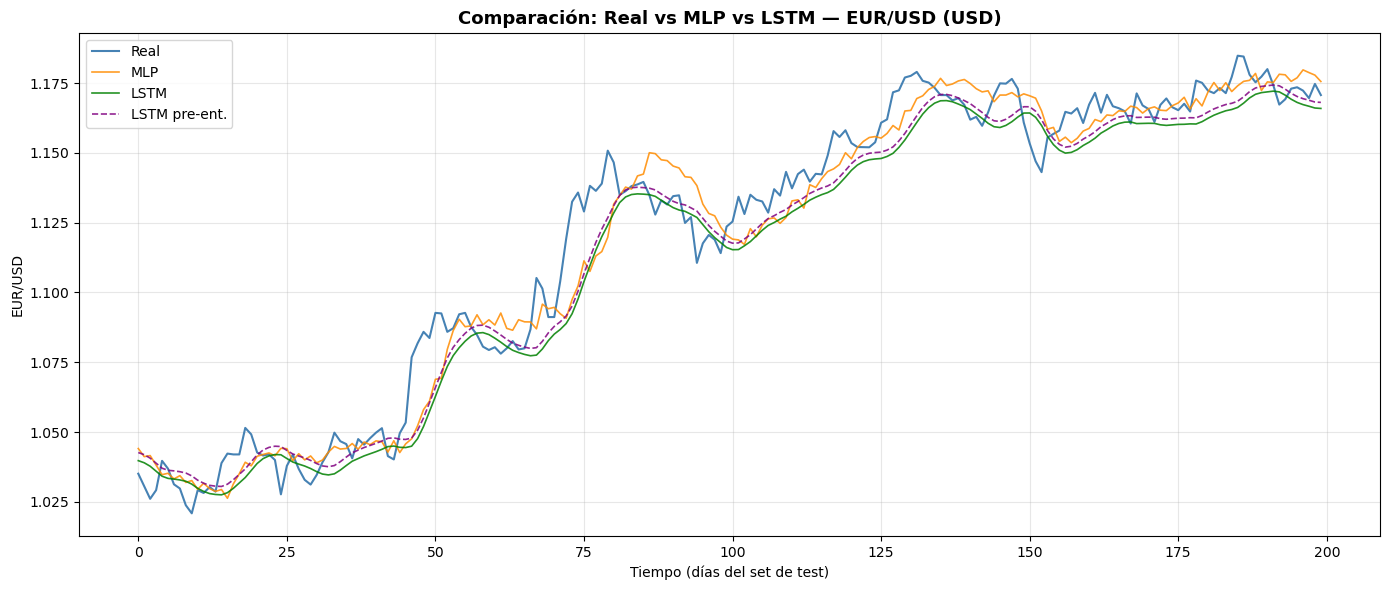

In [91]:
n_muestras = 200
plt.figure(figsize=(14, 6))
plt.plot(resultado_ingenuo['y_real'][:n_muestras], label='Real', color='steelblue', linewidth=1.5)
plt.plot(resultado_mlp['y_pred'][:n_muestras], label='MLP', color='darkorange', linewidth=1.2, alpha=0.85)
plt.plot(resultado_lstm['y_pred'][:n_muestras], label='LSTM', color='green', linewidth=1.2, alpha=0.85)
plt.plot(resultado_preentrenado['y_pred'][:n_muestras], label='LSTM pre-ent.', color='purple', linewidth=1.2, alpha=0.85, linestyle='--')
plt.title('Comparación: Real vs MLP vs LSTM — EUR/USD (USD)', fontsize=13, fontweight='bold')
plt.xlabel('Tiempo (días del set de test)')
plt.ylabel('EUR/USD')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\diego\AppData\Local\Temp\ipykernel_23392\2217686570.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ejes[0].boxplot(


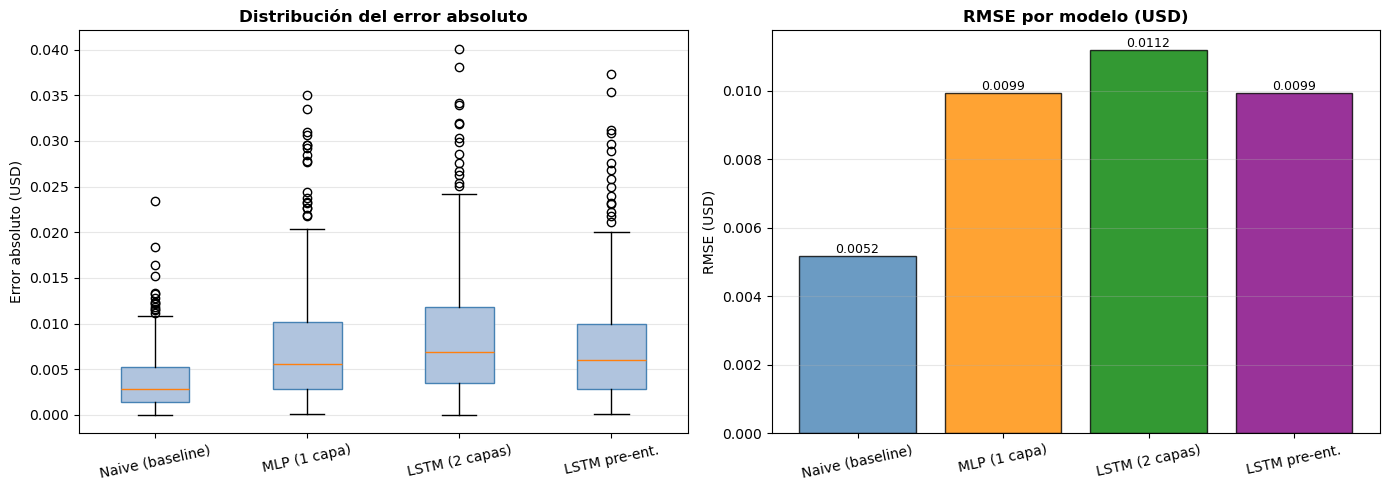

In [92]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

errores_abs = {
    r['nombre']: np.abs(r['y_real'] - r['y_pred']).flatten()
    for r in [resultado_ingenuo, resultado_mlp, resultado_lstm, resultado_preentrenado]
}

ejes[0].boxplot(
    errores_abs.values(),
    labels=errores_abs.keys(),
    patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue', color='steelblue')
)
ejes[0].set_title('Distribución del error absoluto', fontweight='bold')
ejes[0].set_ylabel('Error absoluto (USD)')
ejes[0].grid(alpha=0.3, axis='y')
ejes[0].tick_params(axis='x', rotation=12)

nombres_modelo = [r['nombre'] for r in [resultado_ingenuo, resultado_mlp, resultado_lstm, resultado_preentrenado]]
rmse_modelo = [r['rmse'] for r in [resultado_ingenuo, resultado_mlp, resultado_lstm, resultado_preentrenado]]
colores_modelo = ['steelblue', 'darkorange', 'green', 'purple']
barras = ejes[1].bar(nombres_modelo, rmse_modelo, color=colores_modelo, alpha=0.8, edgecolor='black')
ejes[1].set_title('RMSE por modelo (USD)', fontweight='bold')
ejes[1].set_ylabel('RMSE (USD)')
ejes[1].grid(alpha=0.3, axis='y')
ejes[1].tick_params(axis='x', rotation=12)
for barra, valor in zip(barras, rmse_modelo):
    ejes[1].text(barra.get_x() + barra.get_width() / 2, barra.get_height(), f'{valor:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## BiLSTM sobre Consumo Energético Horario (AEP)


In [93]:
import os
import shutil
import pandas as pd
from pathlib import Path

ruta_aep = Path('AEP_hourly.csv')

if not ruta_aep.exists():
    print('AEP_hourly.csv no encontrado localmente. Intentando descargar con KaggleHub...')
    try:
        import kagglehub
        carpeta_kaggle = Path(kagglehub.dataset_download('robikscube/hourly-energy-consumption'))
        candidatos = sorted(carpeta_kaggle.rglob('*AEP*hourly*.csv'))
        if not candidatos:
            candidatos = sorted(carpeta_kaggle.rglob('*.csv'))
        if not candidatos:
            raise FileNotFoundError('KaggleHub descargó el dataset, pero no se encontró CSV utilizable.')
        origen = candidatos[0]
        shutil.copy2(origen, ruta_aep)
        print(f'Dataset descargado y copiado a: {ruta_aep.resolve()}')
    except Exception as e:
        raise FileNotFoundError(
            'No se encontró AEP_hourly.csv y no fue posible descargarlo desde KaggleHub. '
            'Coloca un CSV real en lab_1.'
        ) from e

datos_crudos_energia = pd.read_csv(ruta_aep)

if 'Datetime' not in datos_crudos_energia.columns:
    raise ValueError('El archivo AEP debe incluir la columna Datetime.')

if 'AEP_MW' in datos_crudos_energia.columns:
    columna_mw = 'AEP_MW'
elif 'MW' in datos_crudos_energia.columns:
    columna_mw = 'MW'
else:
    columnas_extra = [c for c in datos_crudos_energia.columns if c != 'Datetime']
    if not columnas_extra:
        raise ValueError('No se encontró columna de consumo (MW).')
    columna_mw = columnas_extra[0]

datos_energia = datos_crudos_energia[['Datetime', columna_mw]].copy()
datos_energia['Datetime'] = pd.to_datetime(datos_energia['Datetime'], errors='coerce')
datos_energia['MW'] = pd.to_numeric(datos_energia[columna_mw], errors='coerce')
datos_energia = datos_energia.dropna(subset=['Datetime', 'MW'])
datos_energia = datos_energia[['Datetime', 'MW']].set_index('Datetime').sort_index()
datos_energia = datos_energia[~datos_energia.index.duplicated(keep='last')]

print(f'Dataset cargado: {ruta_aep}')
print(f'Registros: {len(datos_energia):,}')
print(f'Periodo: {datos_energia.index[0]} -> {datos_energia.index[-1]}')
print(datos_energia.describe().round(3))

Dataset cargado: AEP_hourly.csv
Registros: 121,269
Periodo: 2004-10-01 01:00:00 -> 2018-08-03 00:00:00
               MW
count  121269.000
mean    15499.651
std      2591.325
min      9581.000
25%     13630.000
50%     15310.000
75%     17200.000
max     25695.000


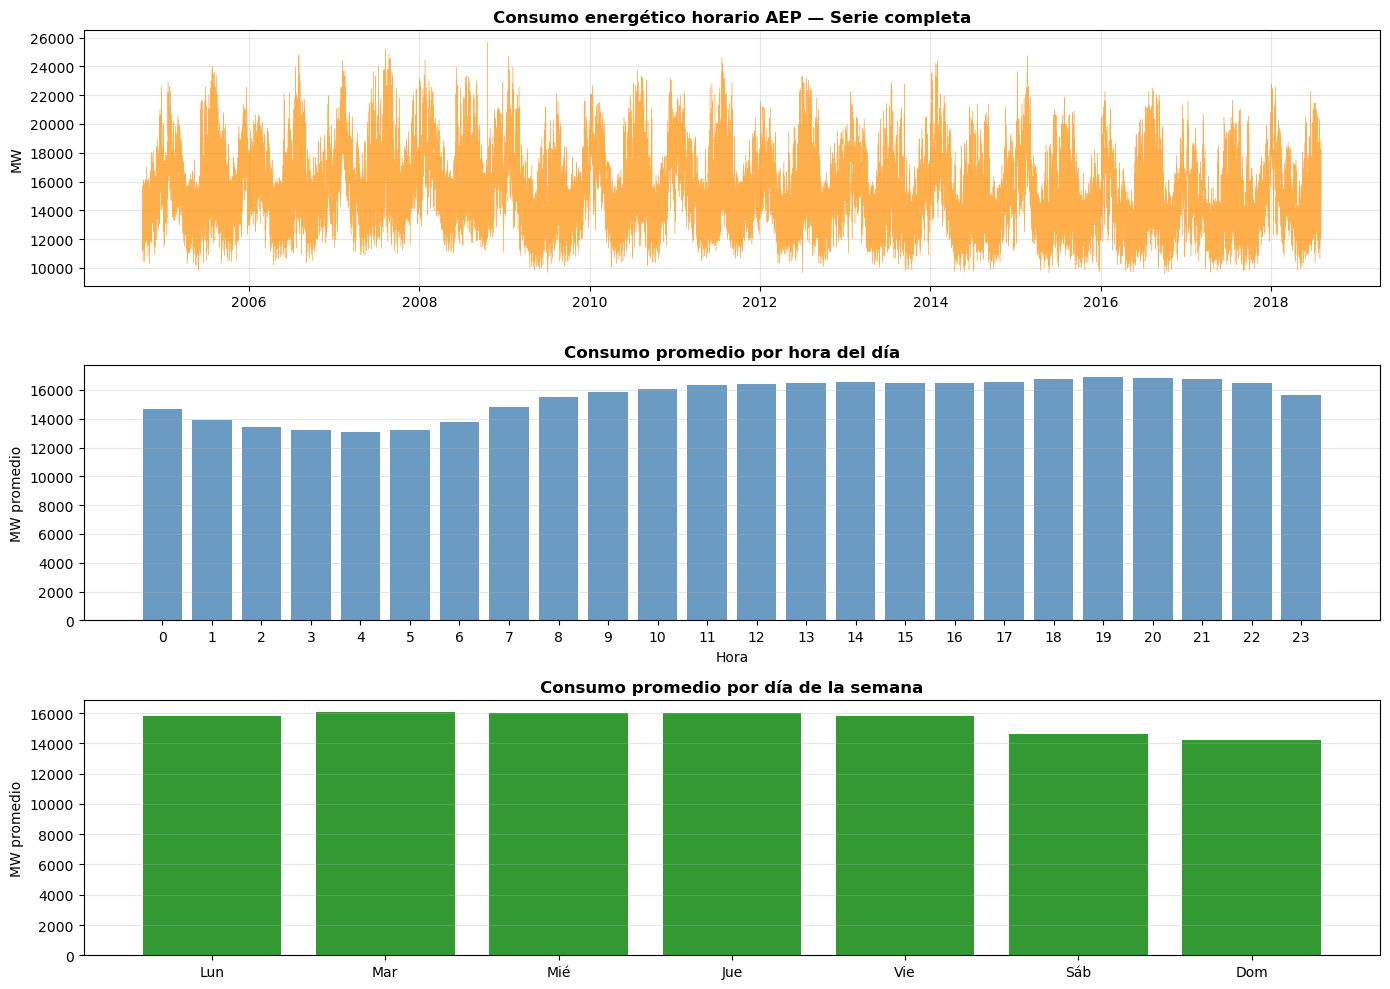

In [94]:
fig, ejes = plt.subplots(3, 1, figsize=(14, 10))

ejes[0].plot(datos_energia.index, datos_energia['MW'], color='darkorange', linewidth=0.3, alpha=0.7)
ejes[0].set_title('Consumo energético horario AEP — Serie completa', fontsize=12, fontweight='bold')
ejes[0].set_ylabel('MW')
ejes[0].grid(alpha=0.3)

datos_energia['hora'] = datos_energia.index.hour
consumo_por_hora = datos_energia.groupby('hora')['MW'].mean()
ejes[1].bar(consumo_por_hora.index, consumo_por_hora.values, color='steelblue', alpha=0.8)
ejes[1].set_title('Consumo promedio por hora del día', fontsize=12, fontweight='bold')
ejes[1].set_xlabel('Hora')
ejes[1].set_ylabel('MW promedio')
ejes[1].set_xticks(range(0, 24))
ejes[1].grid(alpha=0.3, axis='y')

datos_energia['dia_semana'] = datos_energia.index.dayofweek
consumo_por_dia = datos_energia.groupby('dia_semana')['MW'].mean()
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
ejes[2].bar(range(7), consumo_por_dia.values, color='green', alpha=0.8)
ejes[2].set_title('Consumo promedio por día de la semana', fontsize=12, fontweight='bold')
ejes[2].set_xticks(range(7))
ejes[2].set_xticklabels(dias)
ejes[2].set_ylabel('MW promedio')
ejes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [95]:
escalador_energia = MinMaxScaler()
serie_energia = escalador_energia.fit_transform(datos_energia[['MW']].values)

VENTANA_ENTRADA = 168
HORIZONTE_PRED = 24

def crear_secuencias(datos, longitud_ventana, longitud_prediccion):
    """Crea pares (X, y) para predicción multi-paso."""
    x_secuencias, y_secuencias = [], []
    for i in range(len(datos) - longitud_ventana - longitud_prediccion + 1):
        x_secuencias.append(datos[i:i + longitud_ventana])
        y_secuencias.append(datos[i + longitud_ventana:i + longitud_ventana + longitud_prediccion])
    return np.array(x_secuencias), np.array(y_secuencias)

x_energia, y_energia = crear_secuencias(serie_energia, VENTANA_ENTRADA, HORIZONTE_PRED)
print(f'x_energia: {x_energia.shape}   # (muestras, 168, 1)')
print(f'y_energia: {y_energia.shape}   # (muestras, 24, 1)')

total_muestras = len(x_energia)
tam_train_energia = int(total_muestras * 0.70)
tam_val_energia = int(total_muestras * 0.15)

x_energia_train, y_energia_train = x_energia[:tam_train_energia], y_energia[:tam_train_energia]
x_energia_val, y_energia_val = x_energia[tam_train_energia:tam_train_energia + tam_val_energia], y_energia[tam_train_energia:tam_train_energia + tam_val_energia]
x_energia_test, y_energia_test = x_energia[tam_train_energia + tam_val_energia:], y_energia[tam_train_energia + tam_val_energia:]
print(f'Train: {len(x_energia_train):,} | Val: {len(x_energia_val):,} | Test: {len(x_energia_test):,}')

x_energia: (121078, 168, 1)   # (muestras, 168, 1)
y_energia: (121078, 24, 1)   # (muestras, 24, 1)
Train: 84,754 | Val: 18,161 | Test: 18,163


In [96]:
class DatasetEnergia(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, indice):
        return self.x[indice], self.y[indice]

conjuntos_energia = {
    'entrenamiento': DatasetEnergia(x_energia_train, y_energia_train),
    'evaluacion': DatasetEnergia(x_energia_val, y_energia_val),
    'prueba': DatasetEnergia(x_energia_test, y_energia_test)
}

cargadores_energia = {
    'entrenamiento': DataLoader(conjuntos_energia['entrenamiento'], batch_size=256, shuffle=True),
    'evaluacion': DataLoader(conjuntos_energia['evaluacion'], batch_size=256, shuffle=False),
    'prueba': DataLoader(conjuntos_energia['prueba'], batch_size=256, shuffle=False)
}

In [97]:
class ModeloBiLSTM(torch.nn.Module):
    def __init__(self, tam_entrada=1, tam_oculto=64, num_capas=2, longitud_pred=24):
        super().__init__()
        self.red_bilstm = torch.nn.LSTM(
            tam_entrada,
            tam_oculto,
            num_capas,
            batch_first=True,
            dropout=0.2,
            bidirectional=True
        )
        self.capa_salida = torch.nn.Linear(tam_oculto * 2, longitud_pred)

    def forward(self, x):
        salida, _ = self.red_bilstm(x)
        return self.capa_salida(salida[:, -1, :]).unsqueeze(-1)

modelo_bilstm = ModeloBiLSTM(longitud_pred=HORIZONTE_PRED)
print(modelo_bilstm)
print(f'Parámetros: {sum(p.numel() for p in modelo_bilstm.parameters()):,}')

ModeloBiLSTM(
  (red_bilstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (capa_salida): Linear(in_features=128, out_features=24, bias=True)
)
Parámetros: 136,728


In [98]:
def entrenar_bilstm(modelo, cargadores, epocas=50):
    modelo.to(dispositivo)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)
    criterio = torch.nn.MSELoss()
    barra = tqdm(range(1, epocas + 1))
    for epoca in barra:
        modelo.train()
        perdidas_train = []
        for x_lote, y_lote in cargadores['entrenamiento']:
            x_lote, y_lote = x_lote.to(dispositivo), y_lote.to(dispositivo)
            optimizador.zero_grad()
            perdida = criterio(modelo(x_lote), y_lote)
            perdida.backward()
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            optimizador.step()
            perdidas_train.append(perdida.item())

        modelo.eval()
        perdidas_val = []
        with torch.no_grad():
            for x_lote, y_lote in cargadores['evaluacion']:
                x_lote, y_lote = x_lote.to(dispositivo), y_lote.to(dispositivo)
                perdidas_val.append(criterio(modelo(x_lote), y_lote).item())

        barra.set_postfix(train=round(np.mean(perdidas_train), 5), val=round(np.mean(perdidas_val), 5))

entrenar_bilstm(modelo_bilstm, cargadores_energia, epocas=50)

100%|██████████| 50/50 [10:05<00:00, 12.12s/it, train=0.00163, val=0.0022] 


In [99]:
modelo_bilstm.eval()
predicciones_energia_norm, valores_reales_energia_norm = [], []
with torch.no_grad():
    for x_lote, y_lote in cargadores_energia['prueba']:
        predicciones_energia_norm.append(modelo_bilstm(x_lote.to(dispositivo)).cpu().numpy())
        valores_reales_energia_norm.append(y_lote.numpy())

predicciones_energia_norm = np.concatenate(predicciones_energia_norm).squeeze(-1)
valores_reales_energia_norm = np.concatenate(valores_reales_energia_norm).squeeze(-1)

predicciones_mw = escalador_energia.inverse_transform(predicciones_energia_norm.reshape(-1, 1)).reshape(predicciones_energia_norm.shape)
valores_reales_mw = escalador_energia.inverse_transform(valores_reales_energia_norm.reshape(-1, 1)).reshape(valores_reales_energia_norm.shape)

rmse_bilstm = math.sqrt(mean_squared_error(valores_reales_mw.flatten(), predicciones_mw.flatten()))
mape_bilstm = float(np.mean(np.abs((valores_reales_mw - predicciones_mw) / (valores_reales_mw + 1e-8))) * 100)
print(f'BiLSTM — RMSE: {rmse_bilstm:.2f} MW | MAPE: {mape_bilstm:.4f}%')

BiLSTM — RMSE: 756.76 MW | MAPE: 3.6760%


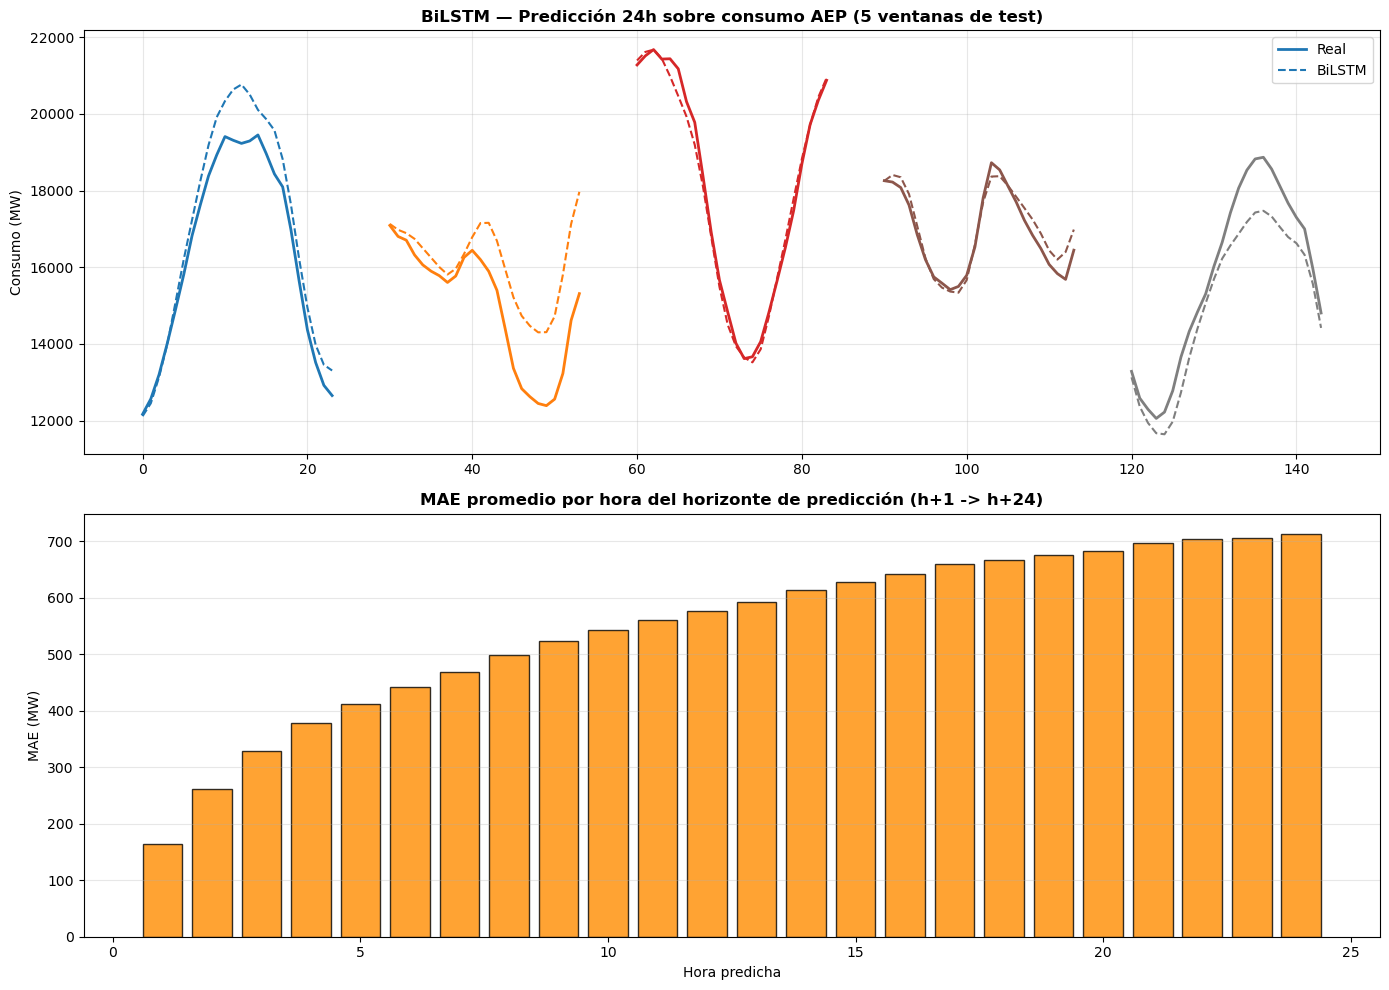

In [100]:
fig, ejes = plt.subplots(2, 1, figsize=(14, 10))

n_ventanas_visualizar = 5
indices = np.linspace(0, len(predicciones_mw) - 1, n_ventanas_visualizar, dtype=int)
colores = plt.cm.tab10(np.linspace(0, 0.7, n_ventanas_visualizar))

for i, (indice, color) in enumerate(zip(indices, colores)):
    desplazamiento = i * (HORIZONTE_PRED + 6)
    eje_tiempo = np.arange(HORIZONTE_PRED)
    ejes[0].plot(eje_tiempo + desplazamiento, valores_reales_mw[indice], color=color, linewidth=2, label='Real' if i == 0 else '')
    ejes[0].plot(eje_tiempo + desplazamiento, predicciones_mw[indice], color=color, linewidth=1.5, linestyle='--', label='BiLSTM' if i == 0 else '')

ejes[0].set_title('BiLSTM — Predicción 24h sobre consumo AEP (5 ventanas de test)', fontsize=12, fontweight='bold')
ejes[0].set_ylabel('Consumo (MW)')
ejes[0].legend(loc='upper right')
ejes[0].grid(alpha=0.3)

error_medio_hora = np.mean(np.abs(valores_reales_mw - predicciones_mw), axis=0)
ejes[1].bar(range(1, HORIZONTE_PRED + 1), error_medio_hora, color='darkorange', alpha=0.8, edgecolor='black')
ejes[1].set_title('MAE promedio por hora del horizonte de predicción (h+1 -> h+24)', fontsize=12, fontweight='bold')
ejes[1].set_xlabel('Hora predicha')
ejes[1].set_ylabel('MAE (MW)')
ejes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()